##**A bit more complex; Water (H$_{2}$O) Molecule!**

<center>
<img src="https://www1.udel.edu/PR/UDaily/2007/mar/Szalewiczfiglg.jpg" width="550">
</center>
Reference of Image: University of Delware

# **Qiskit Workflow**

Reference of water ground state profile energy code: https://github.com/qiskit-community/qiskit-community-tutorials/blob/master/chemistry/h2o.ipynb (With a few changes)

In Qiskit:

##**Qubit Tapering in Qiskit**

Qubit tapering is a technique that reduces the number of qubits required to simulate a quantum system by exploiting its symmetries.

**Mathematical Background**

After mapping a fermionic Hamiltonian to qubits (using Jordan–Wigner, Parity, or Bravyi–Kitaev mappings), the Hamiltonian can be written as

$$
H = \sum_i c_i P_i,
$$

where \(P_i\) are Pauli strings and \(c_i\) are coefficients.

Many molecular Hamiltonians possess **Z$_{2}$ symmetries**. A symmetry operator \(S\) satisfies

$$
[S,H] = 0,
$$

meaning that \(S\) commutes with the Hamiltonian.

Since the eigenvalues of a Z$_{2}$ symmetry are

$$
S|\psi\rangle = \pm |\psi\rangle,
$$

the corresponding qubits have fixed values (\(+1\) or \(-1\)). These qubits do not need to be simulated explicitly and can therefore be removed.

If a Hamiltonian has \(k\) independent Z$_{2}$ symmetries, the number of required qubits can be reduced by \(k\).

### Qubit Tapering in Qiskit

Qiskit Nature can automatically detect Z$_{2}$ symmetries and taper the Hamiltonian:

In [ ]:
from qiskit_nature.second_q.mappers import ParityMapper

# Map fermionic Hamiltonian to qubits
mapper = ParityMapper(num_particles=problem.num_particles)

qubit_hamiltonian = mapper.map(fermionic_hamiltonian)

# Detect Z2 symmetries
z2_symmetries = qubit_hamiltonian.z2_symmetries()

print(z2_symmetries)

To automatically perform tapering:

In [ ]:
from qiskit_nature.second_q.mappers import TaperedQubitMapper

mapper = ParityMapper(num_particles=problem.num_particles)

tapered_mapper = TaperedQubitMapper(mapper)

tapered_hamiltonian = tapered_mapper.map(fermionic_hamiltonian)

In [ ]:
!pip install qiskit_nature
!pip install pyscf

In [ ]:
import numpy as np
import pylab

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.transformers import FreezeCoreTransformer
from qiskit_nature.second_q.mappers import ParityMapper
from qiskit_nature.second_q.algorithms import GroundStateEigensolver

from qiskit_algorithms import NumPyMinimumEigensolver

from qiskit_algorithms.optimizers import SLSQP

from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit_algorithms import VQE
from qiskit.primitives import StatevectorEstimator

In [ ]:
driver = PySCFDriver(atom='O 0.0 0.0 0.0; H 0.757 0.586 0.0; H -0.757 0.586 0.0', charge=0, spin=0, basis='sto3g')
molecule = driver.run()

print(f'Nuclear repulsion energy: {molecule.nuclear_repulsion_energy} Ha')
print(f'Reference energy: {molecule.reference_energy} Ha')
print(f'Number of spin orbitals: {molecule.num_spin_orbitals}')
print(f'Number of alpha electrons: {molecule.num_alpha}')
print(f'Number of beta electrons: {molecule.num_beta}')

Nuclear repulsion energy: 9.193913160623385 Ha
Reference energy: -74.96294665653872 Ha
Number of spin orbitals: 14
Number of alpha electrons: 5
Number of beta electrons: 5


In [ ]:
transformer = FreezeCoreTransformer()
transformed_molecule = transformer.transform(molecule)
mapper = ParityMapper(num_particles=transformed_molecule.num_particles)

algo = NumPyMinimumEigensolver()
algo.filter_criterion = transformed_molecule.get_default_filter_criterion()
solver = GroundStateEigensolver(mapper, algo)
op, _ = solver.get_qubit_operators(transformed_molecule)
print(f'Number of qubits: {op.num_qubits}, number of paulis: {len(op.paulis)}')
result = solver.solve(transformed_molecule)
print(result)

Number of qubits: 10, number of paulis: 551
=== GROUND STATE ENERGY ===
 
* Electronic ground state energy (Hartree): -84.206272446429
  - computed part:      -23.544497240444
  - FreezeCoreTransformer extracted energy part: -60.661775205985
~ Nuclear repulsion energy (Hartree): 9.193913160623
> Total ground state energy (Hartree): -75.012359285806
 
=== MEASURED OBSERVABLES ===
 
  0:  # Particles: 8.000 S: 0.000 S^2: 0.000 M: 0.000
 
=== DIPOLE MOMENTS ===
 
~ Nuclear dipole moment (a.u.): [0.0  2.21475902  0.0]
 
  0: 
  * Electronic dipole moment (a.u.): [0.0  1.578672632401  0.0]
    - computed part:      [0.0  1.577787979435  0.0]
    - FreezeCoreTransformer extracted energy part: [0.0  0.000884652966  0.0]
  > Dipole moment (a.u.): [0.0  0.636086387599  0.0]  Total: 0.636086387599
                 (debye): [0.0  1.616770178304  0.0]  Total: 1.616770178304
 


In [ ]:
tapered_mapper = transformed_molecule.get_tapered_mapper(mapper)
estimator = StatevectorEstimator()

optimizer = SLSQP(maxiter=10000, ftol=1e-9)
ansatz = UCCSD(
    transformed_molecule.num_spatial_orbitals,
    transformed_molecule.num_particles,
    tapered_mapper,
    initial_state=HartreeFock(
    transformed_molecule.num_spatial_orbitals,
    transformed_molecule.num_particles,
    tapered_mapper,
    )
)
vqe = VQE(estimator, ansatz, optimizer)
vqe.initial_point = [0] * ansatz.num_parameters
solver = GroundStateEigensolver(tapered_mapper, vqe)
op, _ = solver.get_qubit_operators(transformed_molecule)
print(f'Number of qubits: {op.num_qubits}, number of paulis: {len(op.paulis)}')

result = solver.solve(transformed_molecule)
print(result)

Number of qubits: 8, number of paulis: 514


/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


=== GROUND STATE ENERGY ===
 
* Electronic ground state energy (Hartree): -84.206171911162
  - computed part:      -23.544396705177
  - FreezeCoreTransformer extracted energy part: -60.661775205985
~ Nuclear repulsion energy (Hartree): 9.193913160623
> Total ground state energy (Hartree): -75.012258750539
 
=== MEASURED OBSERVABLES ===
 
  0:  # Particles: 8.000 S: 0.000 S^2: 0.000 M: -0.000
 
=== DIPOLE MOMENTS ===
 
~ Nuclear dipole moment (a.u.): [0.0  2.21475902  0.0]
 
  0: 
  * Electronic dipole moment (a.u.): [None  1.578662732362  None]
    - computed part:      [None  1.577778079395  None]
    - FreezeCoreTransformer extracted energy part: [0.0  0.000884652966  0.0]
  > Dipole moment (a.u.): [None  0.636096287638  None]  Total: None
                 (debye): [None  1.616795341693  None]  Total: None
 


**Z-Matrix Format**

A Z-matrix describes a molecule using **bond lengths** and **bond angles** instead of Cartesian coordinates \((x,y,z)\).

For example, the water molecule can be written as:

H (its exact position is arbitrary)

O 1 1.08  

H 2 1.08 1 104.5

It means:

Place the oxygen atom:

at a distance of 1.08 Å
from atom 1 (the first hydrogen)

So the O–H bond length is 1.08 Å.

And, place the second hydrogen atom:

1.08 Å from atom 2 (oxygen)

making an angle of 104.5° with atom 1

Therefore:

- The O–H bond length is **1.08 Å**.
- The H–O–H bond angle is **104.5°**.

**Why use a Z-matrix?**

When studying how the molecular energy changes with geometry, it is often easier to modify a bond length or bond angle directly. For example, to change an O–H bond length, only a single parameter needs to be updated in the Z-matrix.

In contrast, with the XYZ format, the atomic coordinates must be recalculated each time the bond length changes.

Therefore, the Z-matrix representation is convenient for geometry scans, potential energy surface calculations, and molecular optimization.

In our code, we can write:

In [ ]:
distances = [x * 0.01 + 1.0 for x in range(15)]
energies = np.empty(len(distances))

for i, distance in enumerate(distances):
    driver = PySCFDriver(f'H; O 1 1.08; H 2 {distance} 1 104.5', basis='sto3g')
    molecule = driver.run()
    transformer = FreezeCoreTransformer()
    transformed_molecule = transformer.transform(molecule)
    mapper = ParityMapper(num_particles=transformed_molecule.num_particles)
    algo = NumPyMinimumEigensolver()
    algo.filter_criterion = transformed_molecule.get_default_filter_criterion()
    solver = GroundStateEigensolver(mapper, algo)
    result = solver.solve(transformed_molecule)
    energies[i] = result.total_energies[0]

Text(0.5, 1.0, 'H2O molecule, one H atom distance varied')

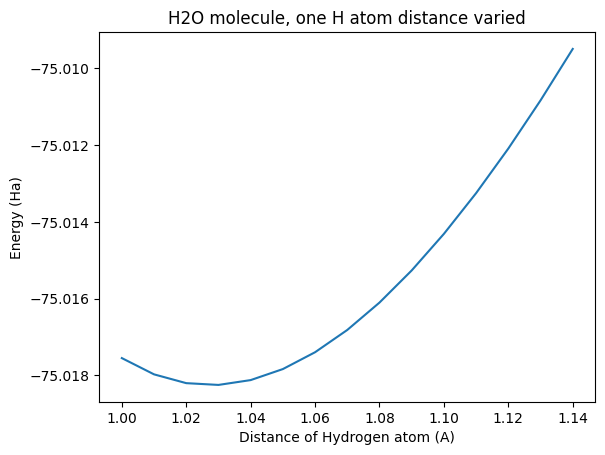

In [ ]:
pylab.plot(distances, energies)
pylab.xlabel('Distance of Hydrogen atom (A)')
pylab.ylabel('Energy (Ha)')
pylab.title('H2O molecule, one H atom distance varied')

## Z$_2$ Symmetry Tapering in PennyLane

When a molecular Hamiltonian is mapped onto qubits, some qubits are associated with conserved quantities (symmetries) of the system. These symmetries can be exploited to reduce the number of qubits required for simulation without changing the physical results.

### Symmetry Operators

A symmetry operator $S$ satisfies

$$
[H,S] = 0,
$$

where $H$ is the molecular Hamiltonian and $[\cdot,\cdot]$ denotes the commutator.

Since $H$ and $S$ commute, they share the same eigenstates. Therefore, the eigenvalue of $S$ remains constant throughout the evolution and optimization process.

---

### Z$_2$ Symmetries

For many molecular Hamiltonians, there exist symmetry operators whose eigenvalues are

$$
s = \pm 1.
$$

These are called Z$_2$ symmetries because the symmetry group contains only two possible values:

$$
\{+1,-1\}.
$$

Examples include:

- Electron-number parity
- Spin parity
- Other fermionic parity symmetries

---

### Main Idea of Tapering

Suppose a symmetry operator has a fixed eigenvalue

$$
S |\psi\rangle = s |\psi\rangle,
\qquad s=\pm1.
$$

Since the value of $S$ is already known, the corresponding qubit does not need to be simulated explicitly.

Instead, PennyLane replaces the operator by its eigenvalue:

$$
S \rightarrow s.
$$

As a result, one qubit can be removed from the Hamiltonian.

---

### Hamiltonian Reduction

The original Hamiltonian may act on many qubits:

$$
H_{\mathrm{full}}
\quad \text{on} \quad n \ \text{qubits}.
$$

After identifying all available Z$_2$ symmetries, PennyLane constructs a tapered Hamiltonian

$$
H_{\mathrm{tapered}}
\quad \text{on} \quad (n-k) \ \text{qubits},
$$

where $k$ is the number of independent symmetry generators.

The energy spectrum inside the chosen symmetry sector remains unchanged.

---

### Example: H$_2$O Molecule

For a water molecule in the STO-3G basis, the qubit Hamiltonian may initially require approximately

$$
14
$$

qubits.

After applying Z$_2$ symmetry tapering, the Hamiltonian often requires only

$$
12
$$

qubits.

Conceptually,

$$
H_{\mathrm{full}}
\,(14 \ \text{qubits})
\longrightarrow
H_{\mathrm{tapered}}
\,(12 \ \text{qubits}).
$$

---

### Benefits

Z$_2$ tapering provides several advantages:

1. Fewer qubits are required.
2. Smaller quantum circuits are generated.
3. Classical simulation becomes faster.
4. Memory consumption is reduced.
5. The ground-state energy is preserved.

---

### PennyLane Workflow

The tapering procedure can be summarized as

$$
\text{Molecule}
\rightarrow
H
\rightarrow
\text{Symmetry Generators}
\rightarrow
\text{Tapered Hamiltonian}.
$$

In PennyLane:

In [ ]:
H, qubits = qml.qchem.molecular_hamiltonian(...)

generators = qml.qchem.symmetry_generators(H)

H_tapered = qml.qchem.taper(...)

In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 67.2 MB/s eta 0:00:00


Number of qubits (no tapering): 12
Number of Pauli terms: 551
Reference (exact) ground state energy: -75.01235929 Ha
Number of qubits after tapering: 8
Number of Pauli terms after tapering: 514
Tapered HF state: [1 1 1 1 1 1 1 0]

Final VQE ground state energy (tapered): -74.96294666 Ha
Optimal parameters: [ 0.0999999   0.          0.          0.09999984 -0.09999976  0.
  0.09999987 -0.09999972  0.          0.          0.09999984  0.
  0.         -0.0999994   0.          0.          0.          0.
  0.          0.         -0.09999972  0.09999987  0.         -0.09999976
 -0.09999984  0.          0.          0.0999994   0.          0.
  0.          0.          0.          0.          0.09999986  0.
  0.          0.09999993  0.09999971  0.          0.09999977 -0.09999987
  0.          0.          0.          0.          0.          0.
  0.         -0.09999987  0.09999977  0.          0.09999971  0.
  0.          0.          0.          0.          0.09999985  0.
  0.          0.09999985  

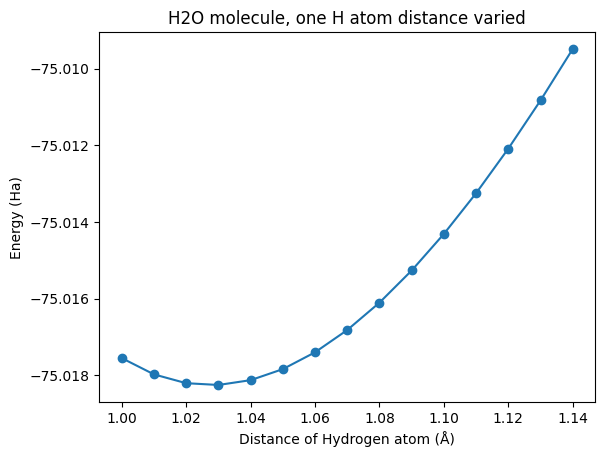

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as pnp

# -----------------------------------------------------------------
# 1. Build the H2O molecule and Hamiltonian
# -----------------------------------------------------------------
symbols = ["O", "H", "H"]
coordinates = np.array([
    [0.0,    0.0,    0.0],
    [0.757,  0.586,  0.0],
    [-0.757, 0.586,  0.0],
])

molecule = qml.qchem.Molecule(
    symbols,
    coordinates,
    unit="angstrom",
    charge=0,
    mult=1,
    basis_name="sto-3g",
)

H, qubits = qml.qchem.molecular_hamiltonian(
    molecule,
    method="pyscf",
    active_electrons=8,
    active_orbitals=6,
)

electrons = 8  # active electrons after freezing core (O 1s frozen)

coeffs, ops = H.terms()
print(f"Number of qubits (no tapering): {qubits}")
print(f"Number of Pauli terms: {len(ops)}")

# -----------------------------------------------------------------
# 2. Exact (NumPy) ground state energy for reference
# -----------------------------------------------------------------
H_sparse = H.sparse_matrix()
eigvals = qml.math.linalg.eigvalsh(H_sparse.toarray())
print(f"Reference (exact) ground state energy: {np.min(eigvals):.8f} Ha")

# -----------------------------------------------------------------
# 3. Symmetry reduction (tapering)
# -----------------------------------------------------------------
generators = qml.qchem.symmetry_generators(H)
paulixops = qml.qchem.paulix_ops(generators, qubits)

hf_state = qml.qchem.hf_state(electrons, qubits)
paulix_sector = qml.qchem.optimal_sector(H, generators, electrons)

H_tapered = qml.taper(H, generators, paulixops, paulix_sector)
H_tapered = qml.simplify(H_tapered)

tapered_qubits = len(H_tapered.wires)
coeffs_t, ops_t = H_tapered.terms()
print(f"Number of qubits after tapering: {tapered_qubits}")
print(f"Number of Pauli terms after tapering: {len(ops_t)}")

hf_tapered = qml.qchem.taper_hf(
    generators, paulixops, paulix_sector,
    num_electrons=electrons, num_wires=qubits
)
print(f"Tapered HF state: {hf_tapered}")

# -----------------------------------------------------------------
# 4. VQE with an ansatz on the tapered Hamiltonian
# -----------------------------------------------------------------
dev = qml.device("lightning.qubit", wires=tapered_qubits)

singles, doubles = qml.qchem.excitations(electrons, qubits)

tapered_doubles = [
    qml.taper_operation(
        qml.DoubleExcitation, generators, paulixops, paulix_sector,
        wire_order=H.wires, op_wires=d
    ) for d in doubles
]
tapered_singles = [
    qml.taper_operation(
        qml.SingleExcitation, generators, paulixops, paulix_sector,
        wire_order=H.wires, op_wires=s
    ) for s in singles
]

num_params = len(tapered_singles) + len(tapered_doubles)

@qml.qnode(dev)
def circuit(params):
    qml.BasisState(hf_tapered, wires=range(tapered_qubits))
    idx = 0
    for op in tapered_doubles:
        op(params[idx])
        idx += 1
    for op in tapered_singles:
        op(params[idx])
        idx += 1
    return qml.expval(H_tapered)

params = pnp.zeros(num_params, requires_grad=True)
opt = qml.AdamOptimizer(stepsize=0.1)

max_iterations = 200
conv_tol = 1e-9
prev_energy = circuit(params)

for n in range(max_iterations):
    params, energy = opt.step_and_cost(circuit, params)
    if np.abs(energy - prev_energy) < conv_tol:
        break
    prev_energy = energy

print(f"\nFinal VQE ground state energy (tapered): {energy:.8f} Ha")
#print(f"Optimal parameters: {params}")

# -----------------------------------------------------------------
# 5. Potential energy surface: vary one O-H distance
# -----------------------------------------------------------------
distances = [round(x * 0.01 + 1.0, 2) for x in range(15)]
energies_pes = np.empty(len(distances))

for i, d in enumerate(distances):
    angle = np.deg2rad(104.5)
    coords = np.array([
        [0.0, 0.0, 0.0],                                  # O
        [1.08, 0.0, 0.0],                                 # H1
        [d * np.cos(angle), d * np.sin(angle), 0.0],       # H2
    ])

    mol_i = qml.qchem.Molecule(
        symbols, coords, unit="angstrom", charge=0, mult=1, basis_name="sto-3g"
    )

    H_i, qubits_i = qml.qchem.molecular_hamiltonian(
        mol_i, method="pyscf", active_electrons=8, active_orbitals=6
    )

    H_i_sparse = H_i.sparse_matrix()
    eigvals_i = qml.math.linalg.eigvalsh(H_i_sparse.toarray())
    energies_pes[i] = np.min(eigvals_i)

plt.plot(distances, energies_pes, marker="o")
plt.xlabel("Distance of Hydrogen atom (Å)")
plt.ylabel("Energy (Ha)")
plt.title("H2O molecule, one H atom distance varied")
plt.show()